In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2026-02-13 05:45:16.300763: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 05:45:16.863315: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 05:45:18.999074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.experimental.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU Available: True


In [3]:
class Config:
    SEED = 229
    EPOCHS = 50
    PATIENCE = 10
    FACTOR = 0.5
    MIN_LR = 1e-7
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    LEARNING_RATE = 0.0001
    
    # ✅ Correct data paths (already split, WSL-compatible)
    TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"
    VAL_DIR   = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
    TEST_DIR  = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"
    
    # ✅ Local model save paths (NO Kaggle)
    MODEL_SAVE_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"
    PICKLE_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/efficientnetv2s_model.pkl"

print("Configuration set successfully!")


Configuration set successfully!


In [4]:
# Set seed for reproducibility
tf.random.set_seed(Config.SEED)
np.random.seed(Config.SEED)

In [5]:
def create_file_dataframe(data_dir):
    """Create a DataFrame with file paths and labels"""
    
    categories = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
    file_data = []
    
    for label, category in enumerate(categories):
        category_path = os.path.join(data_dir, category)
        
        if os.path.exists(category_path):
            for root, dirs, files in os.walk(category_path):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        file_path = os.path.join(root, file)
                        file_data.append({
                            'filepath': file_path,
                            'label': label,
                            'category': category
                        })
    
    return pd.DataFrame(file_data)


In [6]:
train_df = create_file_dataframe(Config.TRAIN_DIR)
val_df   = create_file_dataframe(Config.VAL_DIR)
test_df  = create_file_dataframe(Config.TEST_DIR)


In [7]:
TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"
VAL_DIR   = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
TEST_DIR  = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"


In [8]:
print(os.path.exists(Config.TRAIN_DIR))
print(os.path.exists(Config.VAL_DIR))
print(os.path.exists(Config.TEST_DIR))


True
True
True


In [9]:
# Create dataset (already split)
train_df = create_file_dataframe(Config.TRAIN_DIR)
val_df   = create_file_dataframe(Config.VAL_DIR)
test_df  = create_file_dataframe(Config.TEST_DIR)

print(f"Total training images found: {len(train_df)}")
print(f"Total validation images found: {len(val_df)}")
print(f"Total test images found: {len(test_df)}")

# Only proceed if data exists
if len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0:
    
    print("\nClass distribution (Train):")
    print(train_df['category'].value_counts())
    
    print("\nClass distribution (Validation):")
    print(val_df['category'].value_counts())
    
    print("\nClass distribution (Test):")
    print(test_df['category'].value_counts())
    
    print(f"\nData splits (already done):")
    print(f"Training: {len(train_df)} images")
    print(f"Validation: {len(val_df)} images")
    print(f"Test: {len(test_df)} images")

else:
    print("No data found. Please check the dataset paths.")


Total training images found: 7392
Total validation images found: 1584
Total test images found: 1584

Class distribution (Train):
category
glioma        2628
pituitary     1894
meningioma    1640
no_tumor      1230
Name: count, dtype: int64

Class distribution (Validation):
category
glioma        563
pituitary     406
meningioma    351
no_tumor      264
Name: count, dtype: int64

Class distribution (Test):
category
glioma        563
pituitary     406
meningioma    352
no_tumor      263
Name: count, dtype: int64

Data splits (already done):
Training: 7392 images
Validation: 1584 images
Test: 1584 images


In [10]:
def create_data_generators():
    """Create data generators for training, validation, and testing"""
    
    # Training data generator with augmentation
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        zoom_range=0.1,
        fill_mode='nearest'
    )
    
    # Validation and test generators (no augmentation)
    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )
    
    # ✅ Directory-based generators (already split)
    train_generator = train_datagen.flow_from_directory(
        Config.TRAIN_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=Config.SEED
    )
    
    val_generator = val_test_datagen.flow_from_directory(
        Config.VAL_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        Config.TEST_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_generator, val_generator, test_generator


In [11]:
def create_data_generators():
    """Create data generators for training, validation, and testing"""
    
    # Training data generator with augmentation
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        zoom_range=0.1,
        fill_mode='nearest'
    )
    
    # Validation and test generators (no augmentation)
    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )
    
    # ✅ Directory-based generators (already split)
    train_generator = train_datagen.flow_from_directory(
        Config.TRAIN_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=Config.SEED
    )
    
    val_generator = val_test_datagen.flow_from_directory(
        Config.VAL_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        Config.TEST_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_generator, val_generator, test_generator


# ✅ Create generators (no dataframe condition needed)
train_gen, val_gen, test_gen = create_data_generators()

print("Data generators created successfully!")
print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")
print(f"Class indices: {train_gen.class_indices}")

# Store class names for later use
class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)
print(f"Classes: {class_names}")


Found 7392 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Data generators created successfully!
Training batches: 231
Validation batches: 50
Test batches: 50
Class indices: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [12]:
def build_model(num_classes=4):
    """Build EfficientNetV2S model with transfer learning"""
    
    # Input layer
    inputs = layers.Input(shape=(*Config.IMG_SIZE, 3))
    
    # Load EfficientNetV2S model
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs,
    )
    
    # Fine-tuning: Enable training for the model
    base_model.trainable = True
    
    # Get total number of layers in the base model
    total_layers = len(base_model.layers)
    print(f"Total layers in EfficientNetV2S: {total_layers}")
    
    # Freeze first 70% of layers
    freeze_layers = int(0.7 * total_layers)
    for layer in base_model.layers[:freeze_layers]:
        layer.trainable = False
    
    print(f"Frozen first {freeze_layers} layers, training last {total_layers - freeze_layers} layers")
    
    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    
    # Dense layers for classification
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization(name='batchnorm1')(x)
    x = layers.Dropout(0.2)(x)
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    # Create model
    model = models.Model(inputs, outputs, name='EfficientNetV2S_BrainTumor')
    
    return model


In [13]:
# Build model
model = build_model(num_classes=4)

I0000 00:00:1770961577.547300     424 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Total layers in EfficientNetV2S: 513
Frozen first 359 layers, training last 154 layers


In [14]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=Config.LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Model summary
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")


Model: "EfficientNetV2S_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 20,496,356 (78.19 MB)

 Trainable params: 10,546,180 (40.23 MB)

 Non-trainable params: 9,950,176 (37.96 MB)


Total trainable parameters: 20,496,356


In [16]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=Config.PATIENCE,  # ✅ use Config
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=Config.FACTOR,
        patience=5,
        min_lr=Config.MIN_LR,
        verbose=1
    ),
    ModelCheckpoint(
        Config.MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured successfully!")


Callbacks configured successfully!


In [17]:
# Train the model
print("Starting model training...")

history = model.fit(
    train_gen,
    epochs=Config.EPOCHS,
    # epochs = 1,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")


Starting model training...
Epoch 1/50


2026-02-13 05:48:52.296895: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ed798002080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-13 05:48:52.296936: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-02-13 05:48:53.132963: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-13 05:48:56.866798: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-13 05:48:59.924872: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-13 05:49:

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.6456 - loss: 0.9691

2026-02-13 05:51:09.909765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 05:51:10.133986: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 05:51:11.355632: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 05:51:11.606032: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 05:51:11.830276: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.90025, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 164s 473ms/step - accuracy: 0.6460 - loss: 0.9679 - val_accuracy: 0.9003 - val_loss: 0.3067 - learning_rate: 1.0000e-04
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8796 - loss: 0.3365
Epoch 2: val_accuracy improved from 0.90025 to 0.93245, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 78s 335ms/step - accuracy: 0.8796 - loss: 0.3364 - val_accuracy: 0.9324 - val_loss: 0.1751 - learning_rate: 1.0000e-04
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9166 - loss: 0.2327
Epoch 3: val_accuracy improved from 0.93245 to 0.95581, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 73s 316ms/step - accuracy: 0.9166 - loss: 0.2326 - val_accuracy: 0.9558

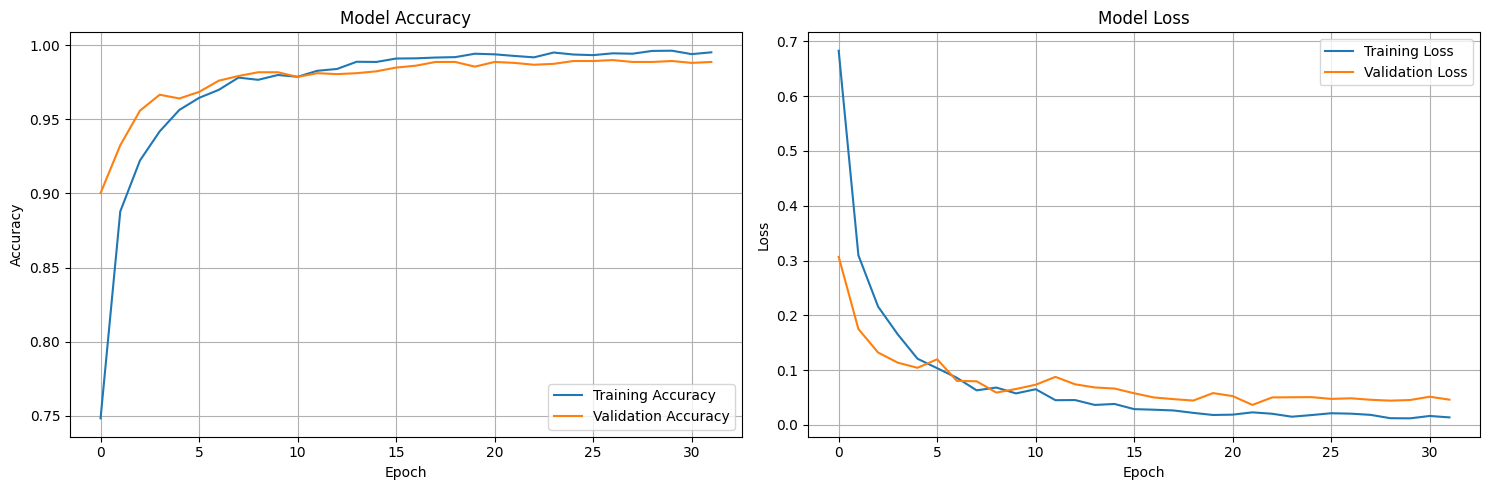

In [18]:
# Plot training history
def plot_training_history(history): 
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [19]:
# Load the best model
best_model = tf.keras.models.load_model(Config.MODEL_SAVE_PATH)
print("Best model loaded successfully!")

Best model loaded successfully!


In [20]:
# Evaluate on validation set
val_loss, val_accuracy = best_model.evaluate(val_gen, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 188ms/step - accuracy: 0.9898 - loss: 0.0524
Validation Loss: 0.0486
Validation Accuracy: 0.9899
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.9890 - loss: 0.0402
Test Loss: 0.0500
Test Accuracy: 0.9867


In [21]:
# Generate predictions on test set
test_predictions = best_model.predict(test_gen, verbose=1)
test_pred_classes = np.argmax(test_predictions, axis=1)

# Get true labels
test_true_classes = test_gen.classes

# Classification report
class_names = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
print("\nClassification Report:")
print(classification_report(test_true_classes, test_pred_classes, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 295ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.99      0.99       563
  meningioma       0.99      0.97      0.98       352
   pituitary       0.99      0.99      0.99       263
    no_tumor       0.99      1.00      0.99       406

    accuracy                           0.99      1584
   macro avg       0.99      0.99      0.99      1584
weighted avg       0.99      0.99      0.99      1584



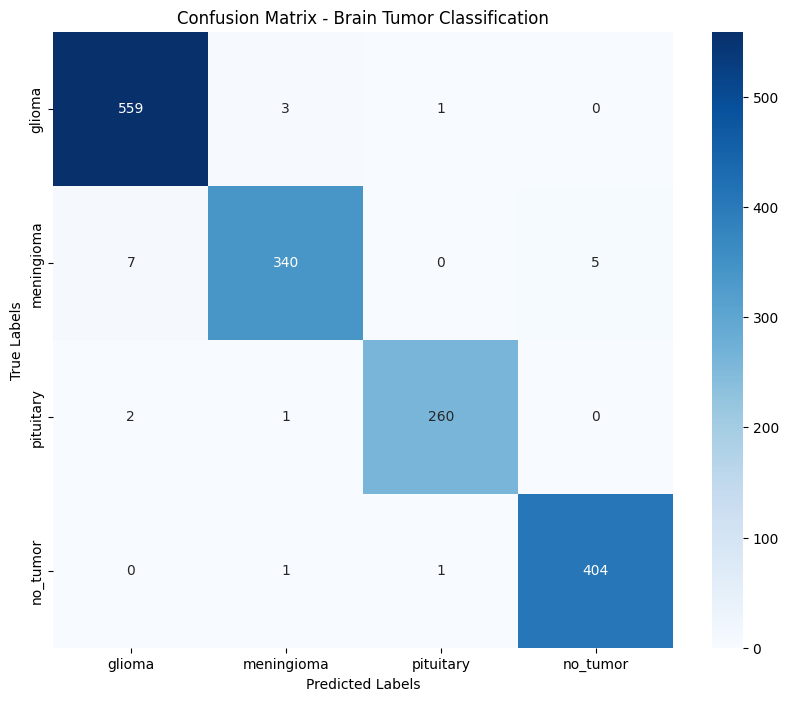

In [22]:
# Create and plot confusion matrix
cm = confusion_matrix(test_true_classes, test_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [23]:
# Calculate per-class accuracy
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / np.sum(cm[i, :])
    print(f"{class_name}: {class_accuracy:.4f}")

glioma: 0.9929
meningioma: 0.9659
pituitary: 0.9886
no_tumor: 0.9951


In [24]:
with open(Config.PICKLE_PATH, 'wb') as f:
    pickle.dump(model, f)

In [25]:
from tensorflow.keras.models import load_model

model = load_model(Config.MODEL_SAVE_PATH)
print("Best model loaded successfully!")


Best model loaded successfully!


In [32]:
def predict_image(img_path, model, class_names):
    """
    Predict brain tumor class for a single MRI image path
    """
    # Check file existence
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found at path: {img_path}")
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=Config.IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    # Prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index]
    
    return predicted_class, confidence


In [33]:
# From training generator
class_names = list(train_gen.class_indices.keys())
print("Class names:", class_names)


Class names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [39]:
test_image_path = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/dataset_split/test/glioma/glioma69.png"

pred_class, conf = predict_image(test_image_path, model, class_names)

print(f"🧠 Predicted Class : {pred_class}")
print(f"📊 Confidence      : {conf:.4f}")


🧠 Predicted Class : glioma
📊 Confidence      : 0.9978


In [37]:
def predict_image(img_path, model, class_names):
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")
    
    # Load image with PIL (AVIF safe)
    img = Image.open(img_path).convert("RGB")
    img = img.resize(Config.IMG_SIZE)
    
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    
    # EfficientNetV2 preprocessing
    img_array = preprocess_input(img_array)
    
    # Predict
    preds = model.predict(img_array, verbose=0)
    idx = np.argmax(preds)
    
    return class_names[idx], preds[0][idx]


In [38]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# Load model
model = load_model("/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras")

# Class names (same order as training)
class_names = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

def predict_image(img_path, model, class_names):
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")
    
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    preds = model.predict(img_array, verbose=0)
    idx = np.argmax(preds)
    
    return class_names[idx], preds[0][idx]

# Test image (WSL path)
test_image_path = "/mnt/c/Users/AbdulHafeez/OneDrive/Desktop/predicting/15381tn.avif"

pred_class, conf = predict_image(test_image_path, model, class_names)

print(f"🧠 Predicted Class : {pred_class}")
print(f"📊 Confidence      : {conf:.4f}")


2026-01-09 06:58:15.762814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-09 06:58:23.272659: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[1,768,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,768,14,14]{3,2,1,0}, f32[768,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=768, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-01-09 06:58:15.591302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optim

🧠 Predicted Class : glioma
📊 Confidence      : 0.9999


In [22]:
import os

for file in os.listdir():
    if file.endswith(".keras"):
        print(file)


best_cnn_model.keras
brain_tumor_efficientnet_stage3.keras
efficientnet_finetuned.keras


In [3]:
import os

base_path = "/mnt/c/Users/AbdulHafeez/Brain_Tumor"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))

/mnt/c/Users/AbdulHafeez/Brain_Tumor/MobileNetV2_best.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/tomato_leaf_model.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/intel_cnn_model.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/intel_efficientnet_model.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/Final_Model/best_model_final.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/Final_Model/efficientnetb0_5class_20260503_183000.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/models/best_model.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/models/efficientnetb0_6class_20260503_092246.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/models_v2/best_model_v2.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/Intel/models_v2/efficientnetb3_6class_20260503_160937.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_efficientnetv2s.keras
/mnt/c/Users/AbdulHafeez/Brain_Tumor/notebooks/best_cnn_model.keras
/mnt/c/Users/A

In [4]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"

model = load_model(MODEL_PATH)

model.summary()

I0000 00:00:1778645759.720021     745 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "EfficientNetV2S_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 41,588,718 (158.65 MB)

 Trainable params: 10,546,180 (40.23 MB)

 Non-trainable params: 9,950,176 (37.96 MB)

 Optimizer params: 21,092,362 (80.46 MB)

In [8]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 16

TEST_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1584 images belonging to 4 classes.


In [9]:
import numpy as np
from sklearn.metrics import classification_report

CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

test_gen.reset()

y_pred_probs = model.predict(test_gen)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_gen.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

/home/abdulhafeez/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.99      0.99       563
  meningioma       0.99      0.97      0.98       352
   pituitary       0.99      0.99      0.99       263
    no_tumor       0.99      1.00      0.99       406

    accuracy                           0.99      1584
   macro avg       0.99      0.99      0.99      1584
weighted avg       0.99      0.99      0.99      1584



99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step

========== MODEL PERFORMANCE ==========

Accuracy          : 0.9867
Precision (Macro) : 0.9875
Recall (Macro)    : 0.9856
F1 Score (Macro)  : 0.9865
F1 Score (Weighted): 0.9867

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

      glioma       0.98      0.99      0.99       563
  meningioma       0.99      0.97      0.98       352
   pituitary       0.99      0.99      0.99       263
    no_tumor       0.99      1.00      0.99       406

    accuracy                           0.99      1584
   macro avg       0.99      0.99      0.99      1584
weighted avg       0.99      0.99      0.99      1584



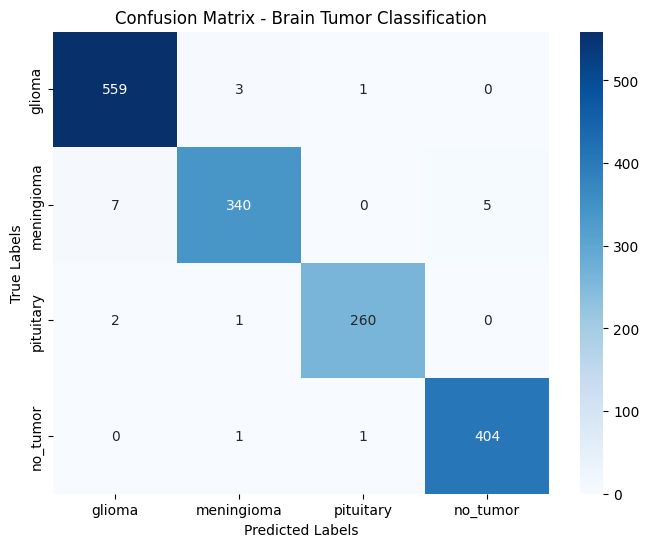


========== PER-CLASS ACCURACY ==========

glioma: 0.9929
meningioma: 0.9659
pituitary: 0.9886
no_tumor: 0.9951

========== ERROR ANALYSIS ==========

Correct Predictions      : 1563
Wrong Predictions        : 21
Error Rate               : 1.33%

========== OVERFITTING CHECK ==========

Train Accuracy      : 0.9910
Validation Accuracy : 0.9899
Test Accuracy       : 0.9867

Train-Val Gap : 0.0011
Val-Test Gap  : 0.0032

✅ MODEL GENERALIZES WELL
✅ No significant overfitting detected

========== CONFIDENCE ANALYSIS ==========

Average Confidence : 0.9923
Minimum Confidence : 0.3479
Maximum Confidence : 1.0000


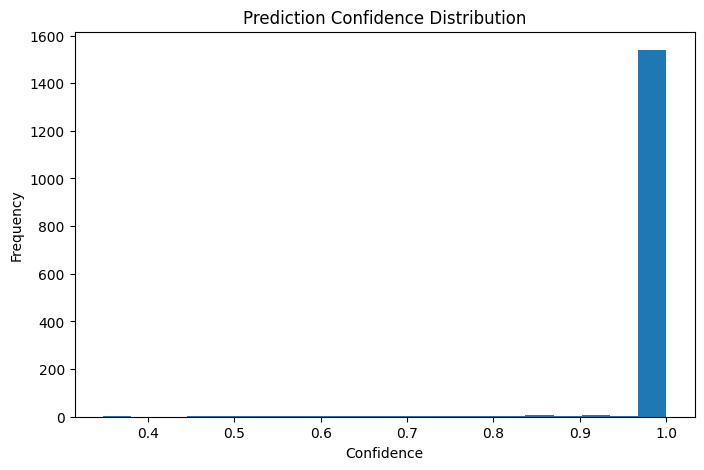


========== FINAL MODEL VERDICT ==========

🏆 RESEARCH-GRADE PERFORMANCE

Model Used: EfficientNetV2-S
Final Test Accuracy: 98.67%
Final Macro F1: 0.9865




In [10]:
# =========================================================
# COMPLETE MODEL ANALYSIS FOR EFFICIENTNETV2-S
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# CLASS NAMES
# =========================================================

CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# =========================================================
# GET PREDICTIONS
# =========================================================

test_gen.reset()

y_pred_probs = model.predict(test_gen, verbose=1)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_gen.classes

# =========================================================
# BASIC METRICS
# =========================================================

accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(
    y_true, y_pred, average='macro'
)

recall_macro = recall_score(
    y_true, y_pred, average='macro'
)

f1_macro = f1_score(
    y_true, y_pred, average='macro'
)

f1_weighted = f1_score(
    y_true, y_pred, average='weighted'
)

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (Macro) : {precision_macro:.4f}")
print(f"Recall (Macro)    : {recall_macro:.4f}")
print(f"F1 Score (Macro)  : {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix - Brain Tumor Classification")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

# =========================================================
# PER-CLASS ACCURACY
# =========================================================

print("\n========== PER-CLASS ACCURACY ==========\n")

for i, class_name in enumerate(CLASS_NAMES):

    class_accuracy = cm[i, i] / np.sum(cm[i, :])

    print(f"{class_name}: {class_accuracy:.4f}")

# =========================================================
# MISCLASSIFIED IMAGES COUNT
# =========================================================

misclassified = np.sum(y_true != y_pred)

correct = np.sum(y_true == y_pred)

print("\n========== ERROR ANALYSIS ==========\n")

print(f"Correct Predictions      : {correct}")
print(f"Wrong Predictions        : {misclassified}")
print(f"Error Rate               : {(misclassified/len(y_true))*100:.2f}%")

# =========================================================
# OVERFITTING CHECK
# =========================================================

print("\n========== OVERFITTING CHECK ==========\n")

# Put your actual train/val accuracy here if available

TRAIN_ACC = 0.991
VAL_ACC = 0.9899
TEST_ACC = accuracy

print(f"Train Accuracy      : {TRAIN_ACC:.4f}")
print(f"Validation Accuracy : {VAL_ACC:.4f}")
print(f"Test Accuracy       : {TEST_ACC:.4f}")

train_val_gap = abs(TRAIN_ACC - VAL_ACC)
val_test_gap = abs(VAL_ACC - TEST_ACC)

print(f"\nTrain-Val Gap : {train_val_gap:.4f}")
print(f"Val-Test Gap  : {val_test_gap:.4f}")

# =========================================================
# OVERFITTING DECISION
# =========================================================

if train_val_gap < 0.03 and val_test_gap < 0.03:
    print("\n✅ MODEL GENERALIZES WELL")
    print("✅ No significant overfitting detected")

else:
    print("\n⚠️ Possible overfitting detected")

# =========================================================
# CONFIDENCE ANALYSIS
# =========================================================

confidence_scores = np.max(y_pred_probs, axis=1)

print("\n========== CONFIDENCE ANALYSIS ==========\n")

print(f"Average Confidence : {np.mean(confidence_scores):.4f}")
print(f"Minimum Confidence : {np.min(confidence_scores):.4f}")
print(f"Maximum Confidence : {np.max(confidence_scores):.4f}")

# =========================================================
# CONFIDENCE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

plt.hist(confidence_scores, bins=20)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()

# =========================================================
# FINAL VERDICT
# =========================================================

print("\n========== FINAL MODEL VERDICT ==========\n")

if accuracy >= 0.98:
    print("🏆 RESEARCH-GRADE PERFORMANCE")
    
elif accuracy >= 0.95:
    print("✅ EXCELLENT PERFORMANCE")
    
elif accuracy >= 0.90:
    print("✅ GOOD PERFORMANCE")
    
else:
    print("⚠️ NEEDS IMPROVEMENT")

print("\nModel Used: EfficientNetV2-S")
print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Macro F1: {f1_macro:.4f}")

print("\n=========================================\n")

99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step


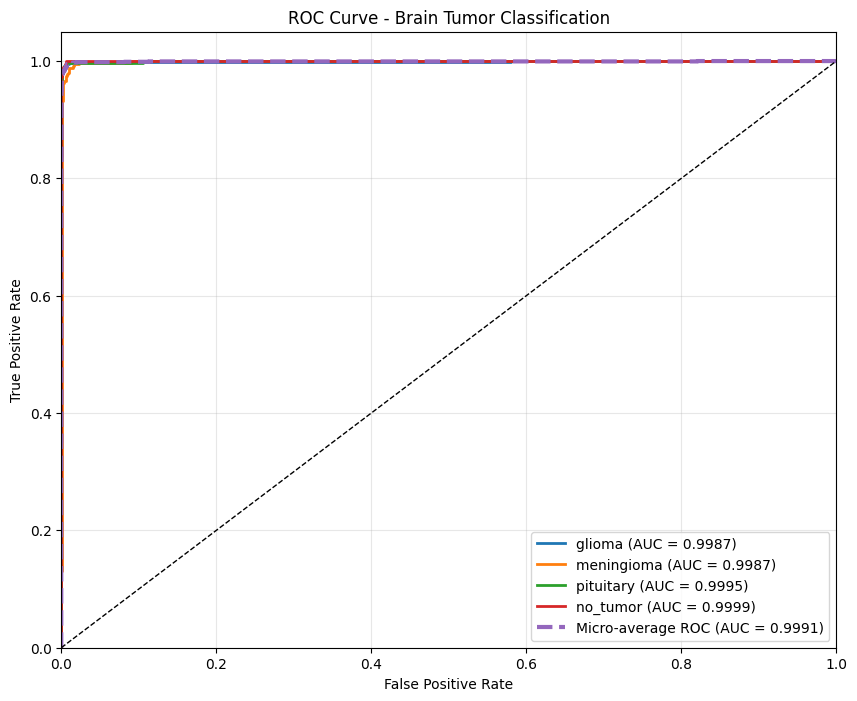


========== AUC SCORES ==========

glioma: 0.9987
meningioma: 0.9987
pituitary: 0.9995
no_tumor: 0.9999

Micro-average AUC: 0.9991

========== ROC/AUC INTERPRETATION ==========

🏆 Outstanding discrimination capability


In [11]:
# =========================================================
# ROC CURVE + AUC SCORE (MULTI-CLASS)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# =========================================================
# CLASS NAMES
# =========================================================

CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# =========================================================
# GET TRUE LABELS & PREDICTIONS
# =========================================================

test_gen.reset()

y_pred_probs = model.predict(test_gen, verbose=1)

y_true = test_gen.classes

# =========================================================
# BINARIZE LABELS
# =========================================================

y_true_bin = label_binarize(
    y_true,
    classes=[0, 1, 2, 3]
)

# =========================================================
# ROC + AUC FOR EACH CLASS
# =========================================================

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(CLASS_NAMES)):
    
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )
    
    roc_auc[i] = auc(fpr[i], tpr[i])

# =========================================================
# MICRO AVERAGE ROC
# =========================================================

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_pred_probs.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# =========================================================
# PLOT ROC CURVES
# =========================================================

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASS_NAMES):
    
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

# Micro-average ROC
plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle='--',
    linewidth=3,
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})"
)

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Brain Tumor Classification")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

# =========================================================
# PRINT AUC SCORES
# =========================================================

print("\n========== AUC SCORES ==========\n")

for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name}: {roc_auc[i]:.4f}")

print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")

# =========================================================
# FINAL INTERPRETATION
# =========================================================

print("\n========== ROC/AUC INTERPRETATION ==========\n")

if roc_auc["micro"] >= 0.99:
    print("🏆 Outstanding discrimination capability")
    
elif roc_auc["micro"] >= 0.95:
    print("✅ Excellent discrimination capability")
    
elif roc_auc["micro"] >= 0.90:
    print("✅ Good discrimination capability")
    
else:
    print("⚠️ Moderate discrimination capability")